In [54]:
import xgboost 

print(xgboost.__version__)

3.0.2


### 파이썬 Native XGBoost 적용 - 위스콘신 Breast Cancer 데이터셋

In [55]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

import xgboost as xgb
from xgboost import plot_importance

import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
features = dataset.data
target = dataset.target

cancer_df = pd.DataFrame(data=features, columns=dataset.feature_names)
cancer_df['target'] = target
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [56]:
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [57]:
X_features = cancer_df.iloc[:,:-1]
y_label = cancer_df.iloc[:,[-1]]

# 전체 데이터 중에 80% 학습 데이터, 20% 테스트 데이터
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label,test_size=0.2,random_state=156)

# 위에서 만든 학습 데이터를 다시 쪼개서 90% 학습 10% 검증 데이터
X_tr, X_val, y_tr, y_val = train_test_split(X_train,y_train, test_size=0.1, random_state=156)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)


(455, 30) (114, 30)
(409, 30) (46, 30)


#### 학습과 예측 데이터 세트를 DMatrix 변환

- DMatrix는 넘파이 array, DataFrame에서도 변환 가능

In [58]:
dtr = xgb.DMatrix(data=X_tr, label=y_tr) # 학습용
dval= xgb.DMatrix(data=X_val, label=y_val) # 검증용
dtest = xgb.DMatrix(data=X_test, label=y_test) # 테스트용


**하이퍼 파리미터 설정**

In [59]:
params = {
    'max_depth':3,
    'eta':0.05, # sklearn 에서는 learning_rate
    'objective':'binary:logistic', # 이진 분류 (sigmoid)
    'eval_metric':'logloss' 
}
num_rounds = 400

**주어진 하이퍼 파라미터와 early stopping 파라미터를 train() 함수의 파라미터로 전달하고 학습**

In [60]:
eval_list = [(dtr,'train'),(dval,'eval')]
xgb_model = xgb.train(params=params, dtrain=dtr, num_boost_round=num_rounds, early_stopping_rounds=50, evals=eval_list)

[0]	train-logloss:0.62473	eval-logloss:0.63088
[1]	train-logloss:0.58662	eval-logloss:0.60461
[2]	train-logloss:0.55210	eval-logloss:0.58205
[3]	train-logloss:0.52068	eval-logloss:0.56165
[4]	train-logloss:0.49173	eval-logloss:0.54101
[5]	train-logloss:0.46517	eval-logloss:0.52206
[6]	train-logloss:0.44009	eval-logloss:0.50271
[7]	train-logloss:0.41646	eval-logloss:0.48606
[8]	train-logloss:0.39505	eval-logloss:0.46961
[9]	train-logloss:0.37523	eval-logloss:0.45485
[10]	train-logloss:0.35682	eval-logloss:0.44120
[11]	train-logloss:0.33964	eval-logloss:0.43123
[12]	train-logloss:0.32279	eval-logloss:0.41962
[13]	train-logloss:0.30783	eval-logloss:0.40848
[14]	train-logloss:0.29308	eval-logloss:0.39857
[15]	train-logloss:0.27928	eval-logloss:0.38945
[16]	train-logloss:0.26681	eval-logloss:0.38171
[17]	train-logloss:0.25498	eval-logloss:0.37381
[18]	train-logloss:0.24352	eval-logloss:0.36656
[19]	train-logloss:0.23307	eval-logloss:0.36014
[20]	train-logloss:0.22290	eval-logloss:0.35395
[2

**predict()를 통해 예측 확률값을 반환하고 예측 값으로 반환**

In [61]:
pred_probs = xgb_model.predict(dtest)
print('predict() 수행 결과를 10개만 표시 확률 값으로 표시됩니다.')
print(np.round(pred_probs[:10], 3))

preds = [ 1 if x > 0.5 else 0 for x in pred_probs]
print("예측값 10개만 표시 ",preds[:10])

predict() 수행 결과를 10개만 표시 확률 값으로 표시됩니다.
[0.938 0.004 0.776 0.058 0.975 1.    0.999 0.999 0.998 0.   ]
예측값 10개만 표시  [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [62]:
pred_probs.shape

(114,)

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가 
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
          F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [64]:
get_clf_eval(y_test, preds, pred_probs)

오차 행렬
[[35  2]
 [ 2 75]]
정확도: 0.9649, 정밀도: 0.9740, 재현율: 0.9740,          F1: 0.9740, AUC:0.9965


**Feature importance 시각화**

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

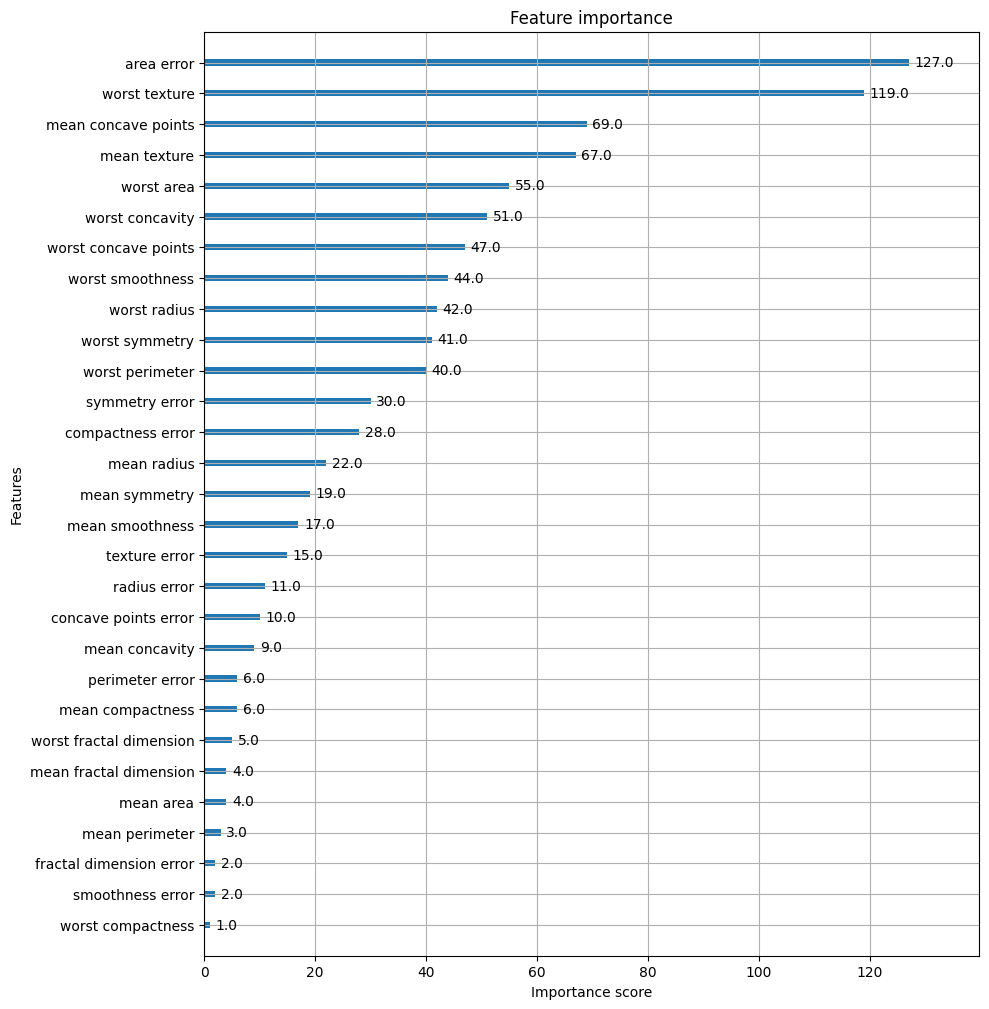

In [65]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_model, ax=ax)

### 사이킷런 Wrapper XGBoost 개요 및 적용 

**사이킷런 래퍼 클래스 임포트, 학습 및 예측**

In [66]:
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, eval_metric='logloss')
xgb_wrapper.fit(X_train, y_train)
w_preds = xgb_wrapper.predict(X_test)
w_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

In [67]:
get_clf_eval(y_test, w_preds, w_pred_proba)

오차 행렬
[[35  2]
 [ 3 74]]
정확도: 0.9561, 정밀도: 0.9737, 재현율: 0.9610,          F1: 0.9673, AUC:0.9947


**early stopping을 50으로 설정하고 재 학습/예측 평가**

In [78]:
from xgboost import XGBClassifier

# 모델 초기화 시점에 early_stopping_rounds와 eval_metric 설정
xgb_wrapper = XGBClassifier(
    n_estimators=400, 
    learning_rate=0.05, 
    max_depth=5, 
    early_stopping_rounds=50, 
    eval_metric='logloss'
)

# fit() 메서드에는 eval_set과 verbose만 전달
evals = [(X_tr, y_tr), (X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, eval_set=evals, verbose=True)


# 예측
ws50_preds = xgb_wrapper.predict(X_test)
ws50_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

[0]	validation_0-logloss:0.62387	validation_1-logloss:0.62700


[1]	validation_0-logloss:0.58495	validation_1-logloss:0.59823
[2]	validation_0-logloss:0.54966	validation_1-logloss:0.57299
[3]	validation_0-logloss:0.51735	validation_1-logloss:0.55040
[4]	validation_0-logloss:0.48791	validation_1-logloss:0.52853
[5]	validation_0-logloss:0.46066	validation_1-logloss:0.50704
[6]	validation_0-logloss:0.43481	validation_1-logloss:0.48815
[7]	validation_0-logloss:0.41158	validation_1-logloss:0.47184
[8]	validation_0-logloss:0.39010	validation_1-logloss:0.45683
[9]	validation_0-logloss:0.37018	validation_1-logloss:0.44222
[10]	validation_0-logloss:0.35167	validation_1-logloss:0.42944
[11]	validation_0-logloss:0.33381	validation_1-logloss:0.41720
[12]	validation_0-logloss:0.31773	validation_1-logloss:0.40596
[13]	validation_0-logloss:0.30255	validation_1-logloss:0.39622
[14]	validation_0-logloss:0.28789	validation_1-logloss:0.38590
[15]	validation_0-logloss:0.27459	validation_1-logloss:0.37752
[16]	validation_0-logloss:0.26224	validation_1-logloss:0.36938
[

In [79]:
print(y_tr.shape)

(409, 1)


In [80]:
get_clf_eval(y_test, ws50_preds, ws50_pred_proba)

오차 행렬
[[36  1]
 [ 2 75]]
정확도: 0.9737, 정밀도: 0.9868, 재현율: 0.9740,          F1: 0.9804, AUC:0.9947


In [81]:
from xgboost import XGBClassifier

# 모델 초기화 시점에 early_stopping_rounds와 eval_metric 설정
xgb_wrapper = XGBClassifier(
    n_estimators=400, 
    learning_rate=0.05, 
    max_depth=5, 
    early_stopping_rounds=10, 
    eval_metric='logloss'
)

# fit() 메서드에는 eval_set과 verbose만 전달
evals = [(X_tr, y_tr), (X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, eval_set=evals, verbose=True)


# 예측
ws50_preds = xgb_wrapper.predict(X_test)
ws50_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]
get_clf_eval(y_test, ws50_preds, ws50_pred_proba)

[0]	validation_0-logloss:0.62387	validation_1-logloss:0.62700
[1]	validation_0-logloss:0.58495	validation_1-logloss:0.59823
[2]	validation_0-logloss:0.54966	validation_1-logloss:0.57299
[3]	validation_0-logloss:0.51735	validation_1-logloss:0.55040
[4]	validation_0-logloss:0.48791	validation_1-logloss:0.52853
[5]	validation_0-logloss:0.46066	validation_1-logloss:0.50704
[6]	validation_0-logloss:0.43481	validation_1-logloss:0.48815
[7]	validation_0-logloss:0.41158	validation_1-logloss:0.47184
[8]	validation_0-logloss:0.39010	validation_1-logloss:0.45683
[9]	validation_0-logloss:0.37018	validation_1-logloss:0.44222
[10]	validation_0-logloss:0.35167	validation_1-logloss:0.42944
[11]	validation_0-logloss:0.33381	validation_1-logloss:0.41720
[12]	validation_0-logloss:0.31773	validation_1-logloss:0.40596
[13]	validation_0-logloss:0.30255	validation_1-logloss:0.39622
[14]	validation_0-logloss:0.28789	validation_1-logloss:0.38590
[15]	validation_0-logloss:0.27459	validation_1-logloss:0.37752
[1

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

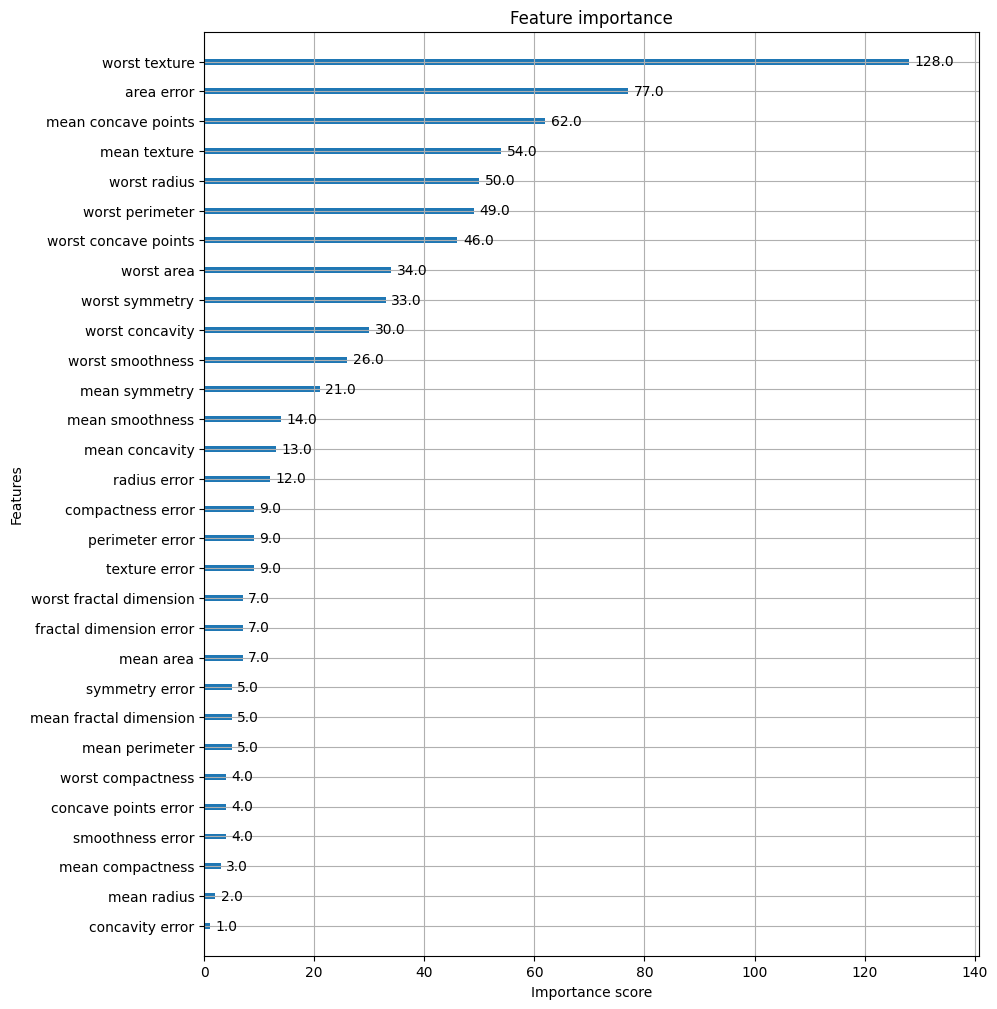

In [83]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))

plot_importance(xgb_wrapper, ax)